voting vs stacking on 3 datasets
---------------------------------------------
iris - hard voting -> 0.96
iris - soft voting -> 0.96
iris - stacking -> 0.967
---------------------------------------------
wine - hard voting -> 0.977
wine - soft voting -> 0.972
wine - stacking -> 0.977
---------------------------------------------
cancer - hard voting -> 0.958
cancer - soft voting -> 0.953
cancer - stacking -> 0.963
---------------------------------------------


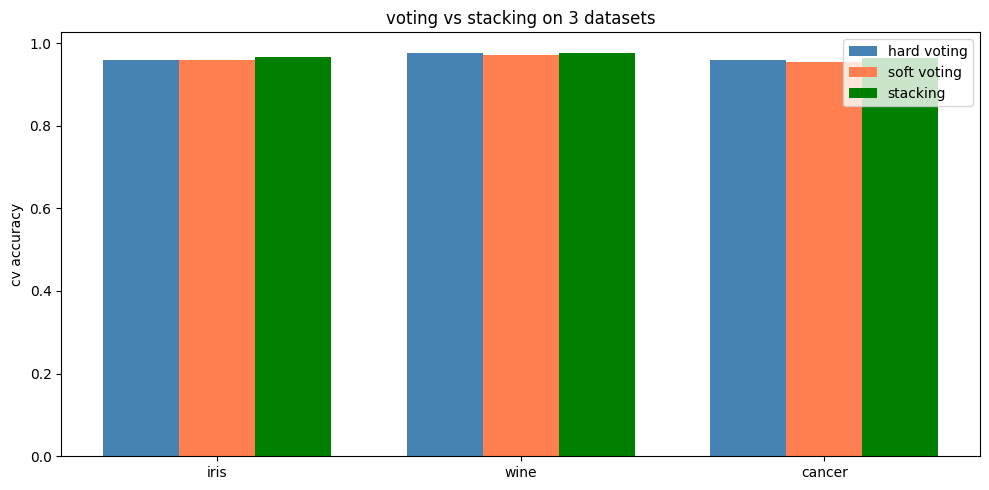

In [4]:
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_breast_cancer, load_wine, load_iris
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

datasets = {
    "iris":   load_iris(),
    "wine":   load_wine(),
    "cancer": load_breast_cancer()
}

base_models = [
    ("dt",  DecisionTreeClassifier(max_depth=4, random_state=42)),
    ("knn", KNeighborsClassifier(n_neighbors=5)),
    ("rf",  RandomForestClassifier(n_estimators=50, random_state=42))
]

hard_vote = VotingClassifier(estimators=base_models, voting="hard")
soft_vote = VotingClassifier(estimators=base_models, voting="soft")
stack = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5
)

results = {name: [] for name in ["hard voting", "soft voting", "stacking"]}

print("voting vs stacking on 3 datasets")
print("-" * 45)

for dname, dataset in datasets.items():
    scaler = StandardScaler()
    x = scaler.fit_transform(dataset.data)
    y = dataset.target

    for name, model in [("hard voting", hard_vote),
                         ("soft voting", soft_vote),
                         ("stacking", stack)]:
        cv = round(np.mean(cross_val_score(model, x, y, cv=5)), 3)
        results[name].append(cv)
        print(dname, "-", name, "->", cv)
    print("-" * 45)

x_pos = np.arange(len(datasets))
width = 0.25

plt.figure(figsize=(10, 5))
plt.bar(x_pos - width, results["hard voting"], width, label="hard voting", color="steelblue")
plt.bar(x_pos, results["soft voting"], width, label="soft voting", color="coral")
plt.bar(x_pos + width, results["stacking"], width, label="stacking", color="green")

plt.xticks(x_pos, datasets.keys())
plt.title("voting vs stacking on 3 datasets")
plt.ylabel("cv accuracy")
plt.legend()
plt.tight_layout()
plt.show()